# Lesson 08a: Theory of NequIP as an E(3)-Equivariant Interatomic Potential

**What you will learn**

- The *atomic energy ansatz*, $E_\mathrm{pot} = \sum_i E_{i,\mathrm{atomic}}$
  and why forces are obtained by autograd.
- The NequIP **interaction block**: convolution filters, $S^{(l)}_m(\vec r_{ij})
  = R(r_{ij})\,Y^{(l)}_m(\hat r_{ij})$, the tensor-product convolution,
  self-interactions, ResNet updates, and the gate nonlinearity.
- How chemistry enters the network: one-hot species embedding and per-species
  energy scale/shift.
- The radial features: trainable **Bessel basis** with a polynomial cutoff
  envelope.
- The empirical result provided by controlled experiments: $l>0$ (equivariant)
  features offer dramatic data efficiency.
- The hyperparameters that define a NequIP model ($l_\text{max}$, channels,
  layers, $r_c$, loss weights).

**Prerequisites**: 

- [Lessons 02b](02b_spherical_harmonics.ipynb): Spherical harmonics,
- [Lesson 03a](03a_tensor_products_theory.ipynb) and [03b](03b_tensor_products_e3nn.ipynb): Tensor products,
- [Lesson 04](04_nonlinearities_and_gates.ipynb): Gates,
- [Lesson 05b](05b_radial_basis_and_cutoffs.ipynb): Radial basis and cutoffs,
- [Lesson 06a](06a_equivariant_convolution.ipynb): Equivariant convolution.

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3
from e3nn.nn import FullyConnectedNet, Gate

from course_utils.data import radius_graph
from course_utils.equivariance import assert_model_equivariant

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)  # Theory notebook: no training, so use float64 throughout
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## The atomic energy ansatz: From positions to energy and forces

NequIP maps the atomic positions, $\{\vec r_i\}$, and chemical species,
$\{Z_i\}$, of a molecule or material to the total potential energy,
$E_\mathrm{pot}$, and the forces, $\{\vec F_i\}$. Following
Behler-Parrinello-style potentials, the total energy of a molecule with
$N_\mathrm{atoms}$ is a **sum of atomic energies** which, in neural networks,
often translates to a scalar value provided by the output node of a graph neural
network (or the output neuron of a dense network):

$$E_\mathrm{pot} \;=\; \sum_{i \,\in\, N_\mathrm{atoms}} E_{i,\mathrm{atomic}}$$

and forces are the **negative gradient of the predicted energy**, computed by automatic differentiation:

$$\vec F_i \;=\; -\nabla_i \, E_\mathrm{pot}$$

Here $\nabla_i$ is the gradient with respect to the position $\vec r_i$ of atom
$i$. This design provides three benefits at once:

1. **Energy conservation:** Because $\vec F = -\nabla E$ by construction, the
   predicted force field is exactly conservative (curl-free), which is essential
   for stable and energy-conserving molecular dynamics simulations.

2. **Permutation invariance:** The sum of atomic energies makes the total
   energy, $E_\mathrm{pot}$, invariant under relabeling of identical atoms.

3. **Locality / linear scaling:** Each atomic energy term,
   $E_{i,\mathrm{atomic}}$, depends only on atoms within a cutoff radius $r_c$
   of atom $i$ (propagated over a few message-passing layers). So, the cost of
   evaluation scales linearly with the number of atoms.

## Features are geometric tensors

As discussed in [Lesson 01a](01a_symmetry_and_equivariance.ipynb), a function
$f\colon X \to Y$ is **equivariant** with respect to a group $G$ acting on $X$
and $Y$ if

$$D_Y(g)\, f(x) \;=\; f\big(D_X(g)\, x\big) \qquad \forall g \in G,\; \forall x \in X$$

where $D_X(g)$, $D_Y(g)$ are the representations of $g$ on the two spaces, $X$
and $Y$, respectively. NequIP is equivariant with respect to $E(3)$, which
involves rotations, translations, and reflections.

The core difference from invariant GNN potentials (e.g., SchNet and DimeNet) is
that the **internal node features are geometric tensors**, not just scalars.
These features, $V^{(l,p)}_{acm}$, carry five indices:

| index | meaning |
|---|---|
| $a$ | atom |
| $c$ | channel (which copy of the irrep, i.e. the "feature dimension") |
| $m \in [-l, l]$ | representation index |
| $l = 0, 1, 2, \dots$ | rotation order of the $O(3)$ irrep |
| $p \in \{1, -1\}$ | parity label (even/odd or `e`/`o` in e3nn notation) |

In e3nn, these features can be exactly represented as `o3.Irreps`. For example,
for a NequIP model with $l_\text{max} = 1$ and 32 channels, the features can be
expressed as `32x0e + 32x0o + 32x1o + 32x1e`. Although the final output,
$E_\mathrm{pot}$, is an invariant scalar (`0e`), the hidden states within the
network involve vectors and higher tensors.

## Architecture overview

The NequIP architecture is a stack of three types of blocks:

- **Embedding:** The initial features are generated using a trainable embedding
  that operates on the atomic numbers, $Z_i$, represented via a one-hot
  encoding. The embedding is implemented via a trainable self-interaction layer
  and the outputs are $l=0$ scalars.

- **Interaction blocks:** The convolution layer plus self-interactions, a ResNet
  skip, and a gate nonlinearity. These layers generate $l>0$ features from the
  scalar ($l=0$) embeddings via coupling them with the edge features.

- **Output block:** The $l=0$ features of the final convolution layers are
  passed to an output block, which consists of a set of two atom-wise
  self-interaction layers. The result is a set of scalars values per atom,
  $E_{i,\mathrm{atomic}}$, which are summed to produce the total energy,
  $E_\mathrm{pot}$.

## Chemical embeddings

The information about chemical species enter the model in two places:

1. **Input embedding:** The atomic numbers, $Z_i$, are one-hot encoded and
   passed through a trainable *self-interaction* block. The self-interaction
   block is an atom-wise linear layer with weights shared across atoms (the same
   idea used in SchNet's embedding). Since a one-hot vector is a collection of
   scalars, the initial features are pure `0e` irreps: rotating the molecule
   does not change what the atoms are.

2. **Output scale/shift:** The predicted atomic energies are scaled and shifted
   by two learnable **per-species** parameters before the sum:

$$\hat E \;=\; \sum_i \sigma_{s_i}\, \hat E_i + \lambda_{s_i}$$

where $s_i$ denotes the species of atom $i$, and $\sigma_{s_i}$, and
$\lambda_{s_i}$ are initialized to 1 and 0 (or to the standard deviation and
mean, calculated from the dataset). This lets the network spend its learning
capacity on the shape (functional form) of the potential-energy surface rather
than on memorizing the absolute per-element energy offsets.

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The ResNet skip connection inside each interaction block also uses
<b>per-species weights</b>.
</div>

Let's implement the embedding layer in e3nn.

In [2]:
# A 4-species one-hot embedding, as a trainable self-interaction on 0e scalars.

# Set the number of species in the dataset (e.g. H, C, N, O)
n_species = 4

# Define the irreps for the one-hot encoding and the embedding
# (one-hot entries are invariant scalars)
irreps_onehot = o3.Irreps(f"{n_species}x0e")
irreps_embed = o3.Irreps("16x0e")

# Create a linear layer that maps from the one-hot encoding to the embedding
embedding = o3.Linear(irreps_onehot, irreps_embed)

Now, we can use the embedding layer to create the initial features for a
five-atom molecule

In [3]:
# Example usage of the embedding layer with a batch of 5 atoms, each represented
# by a species index: 0 = H, 1 = C, 2 = N, 3 = O. 
Z_row = torch.tensor([0, 2, 2, 1, 3])

# Convert the species indices to one-hot encoding ...
one_hot = torch.nn.functional.one_hot(Z_row, n_species).to(torch.get_default_dtype())

# ... and then pass the one-hot encoding through the embedding layer
h0 = embedding(one_hot)

# Print the shapes of the one-hot encoding and the resulting embedding
print(f"Input one-hot: {tuple(one_hot.shape)}  --Linear({irreps_onehot} -> {irreps_embed})-->  h0: {tuple(h0.shape)}")

Input one-hot: (5, 4)  --Linear(4x0e -> 16x0e)-->  h0: (5, 16)


## The convolution filter

Convolutions act on relative positions, $\vec r_{ij} = \vec r_j - \vec r_i$,
(from central atom $i$ to neighbor $j$, matching the sign convention of the
course), which makes them translation invariant. In order to make the
convolutions **rotation equivariant**, the filters are expressed as the product
of learnable radial functions and spherical harmonics:

$$S^{(l)}_m(\vec r_{ij}) \;=\; R(r_{ij})\; Y^{(l)}_m(\hat r_{ij})$$

where $r_{ij} = |\vec r_{ij}|$ and $\hat r_{ij} = \vec r_{ij}/r_{ij}$. All
learnable weights of the filter have been incorporated in the rotationally
invariant radial part, $R(r_{ij})$, while the angular part, $Y^{(l)}_m$, is
fixed. $R(r_{ij})$ is a multi-layer perceptron that produces the radial weights
for every tensor-product path in the layer:

$$R(r_{ij}) \;=\; W_n\, \sigma\big(\cdots \sigma\big(W_2\, \sigma(W_1\, B(r_{ij}))\big)\big)$$

with $\sigma = \mathrm{SiLU}$ and $B(r_{ij}) \in \mathbb{R}^{N_b}$ denotes a
basis embedding of the distance. NequIP uses radial Bessel functions with a
polynomial envelope, $f_\mathrm{env}$, to represent the radial distance:

$$B(r_{ij}) \;=\; \frac{2}{r_c}\,\frac{\sin\!\big(\tfrac{b\pi}{r_c}\, r_{ij}\big)}{r_{ij}} \; f_\mathrm{env}(r_{ij}, r_c).$$

Here, $r_c$ is the cutoff radius which restricts the interactions to $r_{ij} <
r_c$. Also, $b = 1, 2, \dots, N_b$ where $N_b$ is the number of radial basis
functions. The products $b\pi$ are then **optimized by backpropagation** rather
than being fixed. The network uses the polynomial envelope ($f_\mathrm{env}$ )
with $p=6$, which acts on $x = r_{ij}/r_c$ as:

$$f_\mathrm{env}(x) \;=\; 1 - \tfrac{(p+1)(p+2)}{2}\,x^{p} + p(p+2)\,x^{p+1}
- \tfrac{p(p+1)}{2}\,x^{p+2}, \qquad x < 1,$$

and vanishes at $x=1$, together with its first two derivatives. As such, every
filter, and hence the predicted energy, goes smoothly to zero as a neighboring
atom crosses the cutoff sphere. Recall that in Lesson 05b, we explained why this
property is very important for forces and that in Lesson 08b, we will test the
importance of this property.

Let us implement the radial part of the convolution filter in PyTorch and
visualize the Bessel basis functions and the envelope function.

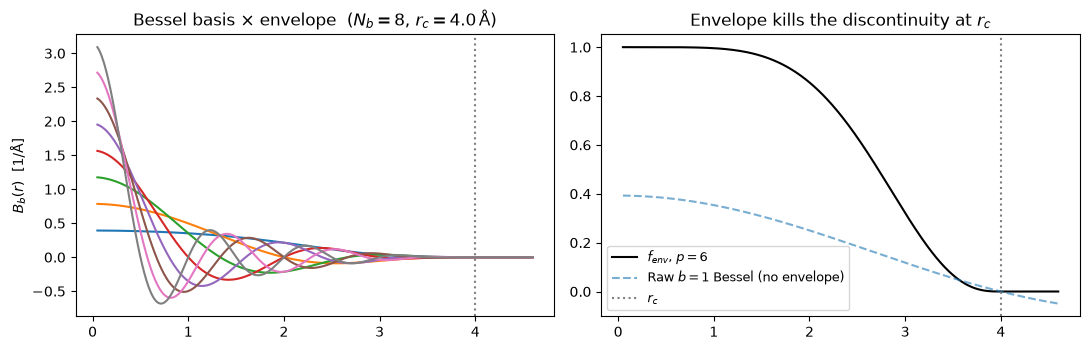

In [4]:
# Set the cutoff radius, the number of Bessel basis functions, and the power of
# the envelope function
r_c, n_basis, p = 4.0, 8, 6

# Create a uniform grid of radial distances from 0.05 to 1.15 times the cutoff
# radius
r = torch.linspace(0.05, 1.15 * r_c, 400)

# Compute the envelope function and the Bessel basis functions
x = r / r_c
f_env = (1 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x**(p + 1)
         - p * (p + 1) / 2 * x**(p + 2)) * (x < 1)

# Bessel roots
b = torch.arange(1, n_basis + 1)

# Compute the Bessel basis functions without the envelope
B = (2 / r_c) * torch.sin(b * torch.pi * x[:, None]) / r[:, None]

# Plot the Bessel basis functions with and without the envelope
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
axes[0].plot(r, B * f_env[:, None])
axes[0].set_title(f"Bessel basis $\\times$ envelope  ($N_b={n_basis}$, $r_c={r_c}\\,$Å)")
axes[0].set_ylabel("$B_b(r)$  [1/Å]")
axes[0].axvline(r_c, color="gray", ls=":", label="$r_c$")
axes[1].plot(r, f_env, "k", label="$f_{env}$, $p=6$")
axes[1].plot(r, B[:, 0], "C0--", alpha=0.6, label="Raw $b=1$ Bessel (no envelope)")
axes[1].axvline(r_c, color="gray", ls=":", label="$r_c$")
axes[1].set_title("Envelope kills the discontinuity at $r_c$")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

## The tensor-product convolution

The convolution filter, $S^{(l_f)}_{m_f}$, and the incoming neighbor feature,
$V^{(l_i,p_i)}$, must be combined *equivariantly*. NequIP uses the geometric
**tensor product** for contracting the tensors using Clebsch–Gordan coefficients
(Lesson 03). A product of input order $l_i$ with filter order $l_f$ produces
outputs of every order according to the **triangle selection rule**:

$$|l_i - l_f| \;\le\; l_o \;\le\; l_i + l_f ,$$

which is often truncated at a chosen $l_\text{max}$, with the **parity selection
rule**

$$ p_o = p_i \, p_f. $$

> Recall that the spherical harmonics have a parity of $p_f = (-1)^{l_f}$.

The full convolutional layer, $\mathcal{L}$, which implements the interaction
$l_i \otimes l_f \to l_o$, can be expressed as:

$$
\mathcal{L}^{\,l_o,p_o,l_f,p_f,l_i,p_i}_{a c m_o}\big(\vec r_a,\, V^{l_i,p_i}_{a c m_i}\big)
\;=\;
\sum_{m_f, m_i} C^{\,l_o, m_o}_{(l_i, m_i)(l_f, m_f)}
\sum_{b \,\in\, S}
\big(R(r_{ab})\big)_{c,\, l_o p_o l_f p_f l_i p_i}\;
Y^{(l_f)}_{m_f}(\hat r_{ab})\; V^{l_i,p_i}_{b c m_i}
$$

where $a$ indexes the central atom, $b \in S$ denotes its neighbors inside $r_c$
and $c$ stands for the channels. Also, $C^{\,l_o,m_o}_{(l_i,m_i)(l_f,m_f)}$ are
the Clebsch–Gordan coefficients (which are independent of parity). The
$\big(R(r_{ab})\big)_{c,\ldots}$ refers to the radial MLP which emits **one
weight per channel and per path** whereas $(l_i,p_i) \otimes (l_f,p_f) \to
(l_o,p_o)$, are evaluated on each edge. In e3nn terms, this translates into a
`TensorProduct` with `shared_weights=False`, whose per-edge weights come from
the radial MLP. All output tensors with the same $(l_o, p_o)$ arising from
different $(l_i, l_f)$ combinations are concatenated and then mixed by a linear
self-interaction layer (next section). The sum over neighbors is divided by $\sqrt{\bar N}$,
where $\bar N$ is the **average number of neighbors** over the training set.
This normalizes the features and keeps them independent of the coordination.

Two especial cases worth mentioning:

- Keeping only $0 \otimes 0 \to 0$ paths collapses the model to a **SchNet-like
  invariant** GNN. The result is a continuous-filter convolution over scalars.

- Allowing $l_\text{max} \ge 1$ makes the messages **directional**: the $l = 1$
  and $l = 2$ components measure the dipole- and quadrupole-like anisotropy of
  the neighbor density, which provides a description of how the neighbors are
  arranged around an atom, not just how far away they are located. This is the
  key trick behind NequIP's data efficiency: the angular resolution on pairwise
  messages, with no triplets to enumerate.

## Self-interaction, ResNet update, and gate

The resulting features from different tensor-product paths, generated by the
convolution layer, $\mathcal{L}$, that yield the same rotarion order and parity,
$(l_o, p_o)$, are concatenated and passed through a series of operations:

- **Self-interaction**: Atom-wise layers, with weights that are shared across
  atoms (similar to SchNet in Lesson 07a), mix the *channels* within each $(l,
  p)$. Here, the same set of weights is applied to all representation indices
  $m$ of a given tensor with rotation order $l$, in order to maintain the
  equivariance. In e3nn, this operation translates to `o3.Linear`.

- The **ResNet-style update** can be defined as:

  $$x^{k+1} \;=\; f(x^k) \;+\; \mathrm{SelfInteraction}(x^k).$$

  Here, $k$ denotes the layer index, and $f$ is the series of self-interaction,
  convolution, concatenation, and self-interaction layers and the weights of the
  $\mathrm{SelfInteraction}$ in the weights are learned separately for each
  chemical species.

- **Gate nonlinearity:** Applying an ordinary activation directly to the
  components of an $l > 0$ tensor would break equivariance. So, the gate treats
  the two kinds of features differently. Scalars ($l = 0$) pass through standard
  pointwise activations: $\mathrm{SiLU}$ for even and $\mathrm{tanh}$ for odd
  parity. Each $l > 0$ feature is instead **gated** or multiplied by its own
  nonlinearly-activated scalar, produced alongside it. Multiplying by a scalar
  rescales a tensor's norm but leaves its direction untouched. Thus, the
  operation is nonlinear yet cannot break equivariance. In e3nn, this operation
  translates to `nn.Gate`.

## Hands-on: One interaction block in e3nn

We now instantiate a single interaction block and watch the irreps flow through
it. 

> We will have the full model, training, and all verification live in Lesson
08b but here, we only want the shapes and the equivariance of one block.

Our toy example involves a system of 5 atoms of one species. The block
parameters are set such that the toy system would yield scalar input features of
type `8x0e` (as they would come out of the embedding), spherical harmonics up to
$l_\text{max} = 2$, and a target feature space `8x0e + 8x0o + 4x1o + 4x1e` for
the block output.

In [5]:
# Set the cutoff radius and the number of Bessel basis functions
r_c, n_basis = 4.0, 8

# Generate random positions for 5 atoms in 3D space
pos = 2.5 * torch.randn(5, 3)

# (2, E): [receiver i, sender j]
edge_index = radius_graph(pos, r_c)
recv, send = edge_index

# r_ij = r_j - r_i
vec = pos[send] - pos[recv]

# Compute the length of each edge vector
r_len = vec.norm(dim=-1)

# Spherical harmonics irreps: 1x0e + 1x1o + 1x2e
irreps_sh = o3.Irreps.spherical_harmonics(2)

# Compute the spherical harmonics for each edge vector
edge_sh = o3.spherical_harmonics(irreps_sh, vec, normalize=True, normalization="component")

# Bessel basis functions with (p = 6) envelope 
x_b = r_len / r_c
f_env = (1 - 28 * x_b**6 + 48 * x_b**7 - 21 * x_b**8) * (x_b < 1)
b = torch.arange(1, n_basis + 1)
edge_basis = (2 / r_c) * torch.sin(b * torch.pi * x_b[:, None]) / r_len[:, None] * f_env[:, None]

# Print the number of atoms, edges, and the shapes of the edge features
print(f"{pos.shape[0]} atoms, {edge_index.shape[1]} edges")
print(f"edge_sh    {tuple(edge_sh.shape)}   irreps: {irreps_sh}")
print(f"edge_basis {tuple(edge_basis.shape)}   (N_b = {n_basis} Bessel functions)")

5 atoms, 6 edges
edge_sh    (6, 9)   irreps: 1x0e+1x1o+1x2e
edge_basis (6, 8)   (N_b = 8 Bessel functions)


In [6]:
# The gate that will terminate the block: split the target irreps into scalars
# (SiLU / tanh) and gated l > 0 features (each gets one extra 0e gate scalar).

# What the block should produce
irreps_out = o3.Irreps("8x0e + 8x0o + 4x1o + 4x1e")

# Split the output irreps into scalars, gated features, and gate scalars
irreps_scalars = o3.Irreps([(m, ir) for m, ir in irreps_out if ir.l == 0])
irreps_gated = o3.Irreps([(m, ir) for m, ir in irreps_out if ir.l > 0])
irreps_gates = o3.Irreps([(m, "0e") for m, _ in irreps_gated])

# Define the activation functions for the scalars based on their parity: even
# parity uses SiLU, and odd parity uses tanh. Then, create a Gate module that
# takes the scalars, applies the appropriate activations, and gates the l > 0
# features with their corresponding gate scalars.
act = {1: torch.nn.functional.silu, -1: torch.tanh}
gate = Gate(irreps_scalars, [act[ir.p] for _, ir in irreps_scalars],
            irreps_gates, [torch.nn.functional.silu for _ in irreps_gates],
            irreps_gated)

# Scalars + gates + gated
print(f"gate input : {gate.irreps_in}")
print(f"gate output: {gate.irreps_out}")

gate input : 8x0o+16x0e+4x1o+4x1e
gate output: 8x0e+8x0o+4x1o+4x1e


In [7]:
# The weighted tensor product h_j (x) Y(r_ij) -> messages, one 'uvu' path per allowed
# (l_i, p_i) x (l_f, p_f) -> (l_o, p_o) combination [selection rules].

# Block input (embedding output)
irreps_in = o3.Irreps("8x0e")
irreps_pre_gate = gate.irreps_in

# Define the tensor product instructions and the intermediate irreps based on the
# selection rules for combining the input irreps with the spherical harmonics
instructions, irreps_mid = [], []
for i_1, (mul, ir_in) in enumerate(irreps_in):
    for i_2, (_, ir_sh) in enumerate(irreps_sh):
        # |l1-l2| <= l_o <= l1+l2, p_o = p1 p2
        for ir_o in ir_in * ir_sh:
            if ir_o in irreps_pre_gate:
                instructions.append((i_1, i_2, len(irreps_mid), "uvu", True))
                irreps_mid.append((mul, ir_o))

# Sort the intermediate irreps and adjust the instructions accordingly
irreps_mid = o3.Irreps(irreps_mid)
irreps_mid, permut, _ = irreps_mid.sort()
instructions = [(i_1, i_2, permut[k], mode, train) for i_1, i_2, k, mode, train in instructions]

# Create the tensor product module that takes the input irreps, spherical harmonics,
# and intermediate irreps, along with the instructions for combining them. The
# weights are not shared and are not internal, meaning they come per edge.
tp = o3.TensorProduct(irreps_in, irreps_sh, irreps_mid, instructions,
                      shared_weights=False, internal_weights=False)

# Create a radial MLP that takes the Bessel basis functions as input and outputs
# the weights for the tensor product. The MLP has 3 hidden layers with 64 units
# each and uses the SiLU activation function. The output dimension of the MLP is
# equal to the number of weights in the tensor product, which is given by
# tp.weight_numel.
radial_mlp = FullyConnectedNet([n_basis, 64, 64, 64, tp.weight_numel],
                               torch.nn.functional.silu)
print(tp)
print(f"radial MLP output = tp.weight_numel = {tp.weight_numel} weights per edge")

TensorProduct(8x0e x 1x0e+1x1o+1x2e -> 8x0e+8x1o | 16 paths | 16 weights)
radial MLP output = tp.weight_numel = 16 weights per edge


We now assemble the remaining self-interactions and push features through, step
by step.

In [8]:
# Self-interaction before the conv
lin_pre = o3.Linear(irreps_in, irreps_in)
lin_post = o3.Linear(irreps_mid.simplify(), irreps_pre_gate)

# ResNet skip: SelfInteraction(x^k)
sc = o3.Linear(irreps_in, irreps_pre_gate)

# Normalize the aggregated messages by the square root of the average number of
# neighbors
avg_n_neighbors = edge_index.shape[1] / pos.shape[0]

# Create a toy system of five atoms, all of the same species (species index 0). 
species = torch.zeros(5, dtype=torch.long)

# Set the embedding size for this block
embed_8 = o3.Linear(irreps_onehot, irreps_in)

# Embed the species information into the input features
h = embed_8(torch.nn.functional.one_hot(species, n_species).to(pos.dtype))

# Print the shape of the input features and the corresponding irreps
print(f"input      h        {tuple(h.shape)}    {irreps_in}")

# Pass the input features through the self-interaction layer before the convolution
x = lin_pre(h)
msg = tp(x[send], edge_sh, weight=radial_mlp(edge_basis))

# Print the shape of the messages and the corresponding intermediate irreps
print(f"messages   (edges)  {tuple(msg.shape)}   {irreps_mid.simplify()}")

# Aggregate the messages by summing over the neighbors for each atom and
# normalizing by the square root of the average number of neighbors. This is
# done using the index_add_ function, which adds the messages to the
# corresponding receiver atoms based on the recv indices.
agg = torch.zeros(pos.shape[0], msg.shape[1]).index_add_(0, recv, msg) / avg_n_neighbors**0.5
print(f"aggregated (atoms)  {tuple(agg.shape)}   (sum over neighbors / sqrt(N))")

# Pass the aggregated messages through the linear layer after the convolution
# and add the skip connection from the self-interaction layer. This is done to
# update the features for the next layer.
y = lin_post(agg) + sc(h)
print(f"pre-gate            {tuple(y.shape)}   {irreps_pre_gate}")

# Pass the updated features through the gate to apply the activation functions
# and gate the l > 0 features with their corresponding gate scalars.
out = gate(y)
print(f"output     x^(k+1)  {tuple(out.shape)}   {gate.irreps_out}")

input      h        (5, 8)    8x0e
messages   (edges)  (6, 32)   8x0e+8x1o
aggregated (atoms)  (5, 32)   (sum over neighbors / sqrt(N))
pre-gate            (5, 48)   8x0o+16x0e+4x1o+4x1e
output     x^(k+1)  (5, 40)   8x0e+8x0o+4x1o+4x1e


<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b>  With pure-scalar (<code>0e</code>) input, layer 1 can only
populate <code>0e</code> (<code>0e</code>$\otimes$<code>0e</code>),
<code>1o</code> (<code>0e</code>$\otimes$<code>1o</code>) and <code>2e</code>
(<code>0e</code>$\otimes$<code>2e</code>). The <code>0o</code>/<code>1e</code>
slots stay zero until layer 2 couples $l > 0$ features to each other.
</div>

### Equivariance check

We wrap the whole block as a function of the atomic positions (the fixed scalar
features cannot break symmetry) and test it against random rotations,
inversions, and translations with the shared course harness. Here, the output
irreps are the gate's output.

In [9]:
def block_on_positions(pos):
    """Wrap the whole block as a function of the atomic positions."""
    
    # Compute the edge indices based on the positions and cutoff radius
    edge_index = radius_graph(pos, r_c)
    
    # Compute the edge vectors and their lengths
    recv, send = edge_index
    vec = pos[send] - pos[recv]
    r_len = vec.norm(dim=-1)
    
    # Compute the spherical harmonics for each edge vector
    edge_sh = o3.spherical_harmonics(irreps_sh, vec, normalize=True, normalization="component")
    
    # Compute the Bessel basis functions with the envelope for each edge length
    x_b = r_len / r_c
    f_env = (1 - 28 * x_b**6 + 48 * x_b**7 - 21 * x_b**8) * (x_b < 1)
    edge_basis = (2 / r_c) * torch.sin(b * torch.pi * x_b[:, None]) / r_len[:, None] * f_env[:, None]
    
    # Pass the input features through the self-interaction layer before the convolution
    x = lin_pre(h)
    
    # Compute the messages by applying the tensor product to the input features
    # and the spherical harmonics, weighted by the radial MLP applied to the
    # Bessel basis functions
    msg = tp(x[send], edge_sh, weight=radial_mlp(edge_basis))
    
    # Aggregate the messages by summing over the neighbors for each atom
    agg = torch.zeros(pos.shape[0], msg.shape[1]).index_add_(0, recv, msg) / avg_n_neighbors**0.5
    
    # Pass the aggregated messages through the linear layer after the
    # convolution and add the skip connection from the self-interaction layer.
    # This is done to update the features for the next layer.
    return gate(lin_post(agg) + sc(h))

In [10]:
# Check the equivariance of the block by applying random rotations, inversions,
# and translations to the atomic positions and verifying that the output
# features transform accordingly. The output irreps are given by the gate's
# output.
assert_model_equivariant(block_on_positions, pos, gate.irreps_out, tol=1e-9)

equivariant!  (max error 4.441e-16 over random O(3) + translations elements)


4.440892098500626e-16

## Forces by autograd = energy conservation for free

NequIP never *predicts* forces with a separate head. It differentiates the
energy with `torch.autograd.grad(E, pos)`. There are consequences to this
design:

- The force field is **exactly conservative**: $\vec F = -\nabla E$ implies
  $\oint \vec F \cdot d\vec l = 0$ on any closed path. Thus, the molecular
  dynamics simulation with a symplectic integrator conserves energy up to
  integration error (i.g., no systematic drift from the model itself).

- **Force equivariance is inherited**: if $E$ is invariant, its gradient
  automatically transforms as a vector, $\vec F_i(R\,\vec r + t) = R\, \vec
  F_i(\vec r)$. There is no extra condition to enforce. Also, under inversion,
  the positions flip sign and so do the forces: The forces are **odd** vectors,
  or `1o`.

- Each training structure supplies $3N$ force labels in addition to 1 energy
  label: a total of $M(3N+1)$ labels from $M$ reference calculations. Training
  on forces is where most of the supervision comes from, which is reflected in
  the loss weighting of Lesson 08b.

## Why $l>0$ features bring data efficiency

The athors of [NequIP manuscript](https://doi.org/10.1038/s41467-022-29939-5)
claim that the model reaches state-of-the-art accuracy with **hundreds to a few
thousand** reference calculations, where earlier deep models used $10^5$–$10^6$
of them to reach the same accuracy. For example, on liquid water,  NequIP
outperforms DeepMD trained on $< 0.1\%$ as much data.

Table 1 of the [NequIP manuscript](https://doi.org/10.1038/s41467-022-29939-5)
shows the performance of different models on predicting the atomic forces in
the **aspirin** molecule (in meV/Å):

| SchNet | DimeNet | sGDML | PaiNN | SpookyNet | GemNet-(T/Q) | **NequIP** ($l=3$) |
|---|---|---|---|---|---|---|
| 58.5 | 21.6 | 29.5 | 14.7 | 11.2 | 9.4 | **8.0** |

**Is the performance gain really because of the equivariance?** In order to
isolate the effect of equivariance on the observed performance, the authors
setup a set of experiments, in which networks with identical hyperparameters
were trained on bulk-water data but with modified expressive capacity to capture
the interactions at different levels by switching between full tensor features
($l \in \{1,2,3\}$) and scalars only ($l=0$, which gives an invariant
SchNet-style model). The results are summarized below:

- Equivariant networks ($l \ge 1$) **outperform the invariant ones at every
  training-set size** (Fig. 5 of the [NequIP
  manuscript](https://doi.org/10.1038/s41467-022-29939-5)).

- Fig. 5 of the manuscript also demonstrates that the learning curves typically
  follow a power law $\epsilon \propto a N^{b}$ whose exponent $b$ (log-log
  slope) is fixed for a given data set, with various methods differing only in
  the offset $a$. The equivariant networks show a **different, steeper log-log
  slope** than the invariant version: The equivariance changes **how fast** the
  model learns from new data, not just where it starts learning.

- Controlled experiments, focusing on weights, features and rotation orders,
  $l$: The weight-contrilled experiments involved a $l=0$ network with increased
  feature sizes to match the number of parameters in a $l=1$ variant. Howver,
  the feature-controlled experiment involved a $l=0$ network with 4 $\times$
  features (`64x0o + 64x0e + 64x1o + 64x1e`) than the $l=0$ NequIP variant with
  (`64x0e`) features. Both weight- and feature-controlled experiments show
  qualitatively the same performance gap. Thus, the observed trends in the
  learnin curve are not about the parameter count.

- Against a Behler–Parrinello neural network, which was trained on 1303 water
  structures and evaluated on 290 test structures (with a force RMSE of
  $\approx$ 120 meV/Å), NequIP ($l=2$) reaches RMSEs of 123.3 and 98.3 meV/Å
  with only **100** and **250** training structures, respectively.

The observations mentioned above delineate that an $l=0$ model must reconstruct
the angular information indirectly through overlaps of many radial filters
across layers. In comparison, an equivariant model captures this information
natively where each message already says: "the neighbor density around me points
this way"! with dipole ($l=1$), quadrupole ($l=2$), ... resolution, and tensor
products let those geometric moments interfere coherently across layers. 

It will be instructive to take a closer look at the learning curves of LiPS
system by taking the corresponding data from Table 4 of the [NequIP
manuscript](https://doi.org/10.1038/s41467-022-29939-5).

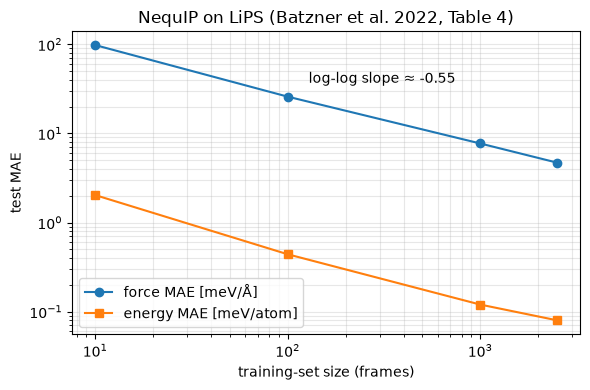

In [11]:
# NequIP force/energy MAE vs training-set size on LiPS
# (values transcribed from Batzner et al. 2022, Table 4).

# The training-set sizes (in frames)
sizes = np.array([10, 100, 1000, 2500])

# The mean absolute errors (MAE) for forces and energies, in meV/Å and meV/atom,
# respectively
f_mae = np.array([97.8, 25.8, 7.7, 4.7])
e_mae = np.array([2.03, 0.44, 0.12, 0.08])

# Fit a linear model to the log-log data for the force MAE and annotate the
# slope on the plot.
slope = np.polyfit(np.log(sizes), np.log(f_mae), 1)[0]

# Plot the force and energy MAE against the training-set size on a log-log
# scale.
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(sizes, f_mae, "o-", label="force MAE [meV/Å]")
ax.loglog(sizes, e_mae, "s-", label="energy MAE [meV/atom]")
ax.annotate(f"log-log slope ≈ {slope:.2f}", (sizes[1], f_mae[1]), textcoords="offset points",
            xytext=(15, 10))
ax.set_xlabel("training-set size (frames)")
ax.set_ylabel("test MAE")
ax.set_title("NequIP on LiPS (Batzner et al. 2022, Table 4)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Summary

- NequIP predicts the total energy of a system as the **sum of atomic energies**
  and computes the atomic forces using **autograd** which gives conservative
  forces by construction.
- The interaction block is build from self-interaction $\to$ tensor-product
  convolution with filters $S^{(l)}_m = R(r)\, Y^{(l)}_m(\hat r)$ $\to$
  concatenate + self-interaction $\to$ ResNet skip $\to$ gate nonlinearity.
  All learnable filter weights come from the radial MLP on a trainable
  Bessel $\times$ polynomial-envelope basis.
- Parity and rotation-order selection rules define which tensor-product paths
  exist. Truncating the ruls at $l_\text{max} = 0$ recovers an invariant
  SchNet-like model.
- The $l>0$ features are the source of NequIP's **data efficiency**: better
  accuracy at every training-set size and a steeper learning-curve slope, which
  remains robust to parameter-count controlled experiments.
- We instantiated one interaction block, traced the irreps flowing through
  it, and verified its $E(3)$-equivariance numerically.

**Next**: [Lesson 08b](08b_nequip_implementation.ipynb) assembles the
aforementioned blocks into a complete `SimpleNequIP` model which satisfies the
energy invariance, force covariance, and cutoff smoothness.

## Exercises

**1.** With input irreps `8x0e + 8x1o` and filter irreps `1x0e + 1x1o + 1x2e` ($l_\text{max} = 2$), list every allowed output irrep $(l_o, p_o)$ with its multiplicity, applying both selection rules. Which outputs would an invariant model ($l_\text{max} = 0$) retain?

<details><summary>Solution</summary>

- From `0e` inputs:
    + $0e\otimes 0e \to 0e$,
    + $0e \otimes 1o \to 1o$,
    + $0e \otimes 2e \to 2e$ (8 each).
- From `1o` inputs:
    + $1o \otimes 0e \to 1o$,
    + $1o \otimes 1o \to 0e, 1e, 2e$,
    + $1o \otimes 2e \to 1o, 2o, 3o$ (8 each; $3o$ dropped if $l_\text{max}=2$).
- Total (with $l_\text{max} = 2$): 
    + $16\times 0e$,
    + $24 \times 1o$,
    + $8 \times 1e$,
    + $16 \times 2e$,
    + $8\times 2o$. 
    
An invariant model keeps only $0e \otimes 0e \to 0e$: `8x0e`. Note every parity
obeys $p_o = p_i p_f$ with $p_f = (-1)^{l_f}$ for spherical harmonics.
</details>

**2.** The envelope $f_\mathrm{env}$ with $p=6$ satisfies $f(1)=f'(1)=f''(1)=0$.
Verify the $f'(1)=0$ claim analytically from the functional form of the
polynomial presented in the text, and explain why smoothness of $E(r)$ *at the
cutoff* matters for MD simulations even though the model is trained only on
configurations with all kinds of interatomic distances.

<details><summary>Solution</summary>

$f(x) = 1 - 28x^6 + 48x^7 - 21x^8 \Rightarrow f'(x) = -168x^5 + 336x^6 -
168x^7$, 

so,

$f'(1) = -168 + 336 - 168 = 0$ (and $f''(1) = -840 + 2016 - 1176 =
0$). 

During MD simulations, atoms continuously cross the cutoff sphere. If the filter
jumped at $r_c$, the energy would be discontinuous and the force would contain a
delta-like spike each crossing: heating the system and destroying energy
conservation regardless of how well the model fits the training set.
</details>

**3.** Why must the radial weights, $R(r_{ij})$, be scalars per path/channel
rather than, say, functions of the full vector $\vec r_{ij}$? What would break
if the weights depended on $\hat r_{ij}$ directly?

<details><summary>Solution</summary>

The convolution filter, $S(\vec r_{ij})$, must transform as an irrep of $O(3)$.
Factorizing $S(\vec r_{ij}) = R(r_{ij})\, Y^{(l)}_m(\hat r_{ij})$ puts **all**
angular dependence into $Y^{(l)}_m(\hat r_{ij})$, whose transformation under
rotation is exactly the Wigner matrix $D^{(l)}$ which is what makes the
Clebsh-Gordan contraction equivariant. The $r_{ij}$ is invariant under rotation
(since it's a scalar). So, any learnable function of it preserves the
equivariance. If weights depended on $\hat r_{ij}$ in an unconstrained way, the
filter would no longer transform as $D^{(l)}$, the CG algebra would not be
closed, and equivariance (and with it the exact force covariance) would be lost.
</details>

## References

- [Batzner et al., *NequIP: E(3)-equivariant graph neural networks for data-efficient and accurate interatomic potentials* Nat. Commun. 13 2453 (2022)](https://doi.org/10.1038/s41467-022-29939-5)
- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Thomas et al., *Tensor Field Networks* arXiv.1802.08219 (2018)](https://arxiv.org/pdf/1802.08219)